**Проект SPAMBASE**



Подключим все необходимые библиотеки

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
import random

from torch.utils.data import TensorDataset, DataLoader

from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid, KFold
from sklearn.metrics import accuracy_score

In [96]:
# Список имён для 57 признаков (взят из документации UCI)
word_freq_cols = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference'
]

char_freq_cols = [
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#'
]

capital_cols = [
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

# Все имена признаков (57)
feature_names = word_freq_cols + char_freq_cols + capital_cols
print(f"Общее количество признаков: {len(feature_names)}")

Общее количество признаков: 57


In [97]:
dataset = pd.read_csv("/content/drive/MyDrive/spambase.data",
                 header = None,
                names=feature_names + ['spam'])
#dataset.rename(columns={dataset.columns[-1]: 'класс'}, inplace=True)
#print(dataset.head())

Давайте получим базовое описание текущего dataset
Для начала рассмотрим несколько случайных фич и то, как они отражаются на классификации : (спам / не спам
)

In [98]:
random.seed(42)
features = dataset.columns[:-1]

cols = random.sample(list(features), 5)
#print(cols)
#cols = cols.append(pd.Index([dataset.columns[-1]]))
cols = cols + [dataset.columns[-1]]
#print(cols)
dataset.loc[:, cols].describe()
#dataset.sample(6).describe()

,word_freq_cs,word_freq_internet,word_freq_address,word_freq_conference,word_freq_email,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.043667,0.105295,0.213015,0.031869,0.184745,0.394045
std,0.361205,0.401071,1.290575,0.285735,0.531122,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,7.140000,11.110000,14.280000,10.000000,9.090000,1.000000


In [99]:
dataset.groupby('spam').mean()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
spam,,,,,,,,,,,,,,,,,,,,,
0,0.073479,0.244466,0.200581,0.000886,0.181040,0.044544,0.009383,0.038415,0.038049,0.167170,...,0.051227,0.050281,0.158578,0.022684,0.109984,0.011648,0.021713,2.377301,18.214491,161.470947
1,0.152339,0.164650,0.403795,0.164672,0.513955,0.174876,0.275405,0.208141,0.170061,0.350507,...,0.002101,0.020573,0.108970,0.008199,0.513713,0.174478,0.078877,9.519165,104.393271,470.619415


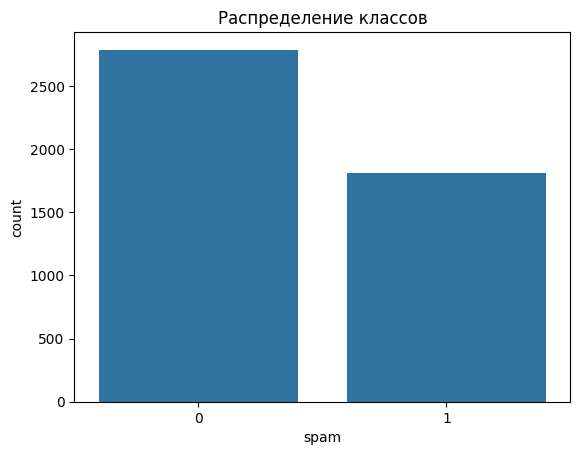

spam
0    0.605955
1    0.394045
Name: proportion, dtype: float64


In [100]:
sns.countplot(x='spam', data=dataset)
plt.title('Распределение классов')
plt.show()

print(dataset['spam'].value_counts(normalize=True))

**Выясним теперь такую вещь:**
1) Рассмотрим среднюю частоту каждого признака для писем - спама и писем - не спама
2) Найдем отношение средней частоты каждого признака в письмах-спаме к средней частоте в признаках не спаме
3) Определим те признаки, которые гораздо чаще встречаются в спаме, нежели не в спаме
4) Выдвигаем гипотезу, что эти признаки больше коррелируют со спамом

In [101]:
#new_df = np.sum(dataset['spam'==1])
#new_df = new_df/(len(dataset))
spam_df = dataset[dataset['spam']== 1]
no_spam_df = dataset[dataset['spam']== 0]
spam_df.drop(columns =['capital_run_length_total',
                       'capital_run_length_longest',
                       'capital_run_length_average', 'spam'], inplace = True)

no_spam_df.drop(columns =['capital_run_length_total',
                        'capital_run_length_longest',
                        'capital_run_length_average', 'spam'], inplace = True)
spam_df = (spam_df.sum(axis = 0)/((len(dataset))))
no_spam_df = (no_spam_df.sum(axis =0)/((len(dataset))))
otnos_df = spam_df / no_spam_df
#print(type(new_df))
#new_df = new_df.sort_values(ascending=False)
otnos_df = otnos_df.sort_values(ascending=False)
#print(no_spam_df)
#print(new_df)
print(otnos_df.head())


word_freq_3d        120.870445
word_freq_000        22.667510
word_freq_remove     19.086774
word_freq_credit     17.634169
char_freq_$           9.740393
dtype: float64


Изобразим гистограммы для распределения признаков, характеризующихся наиболее высокими значениями в предыдущем разделе

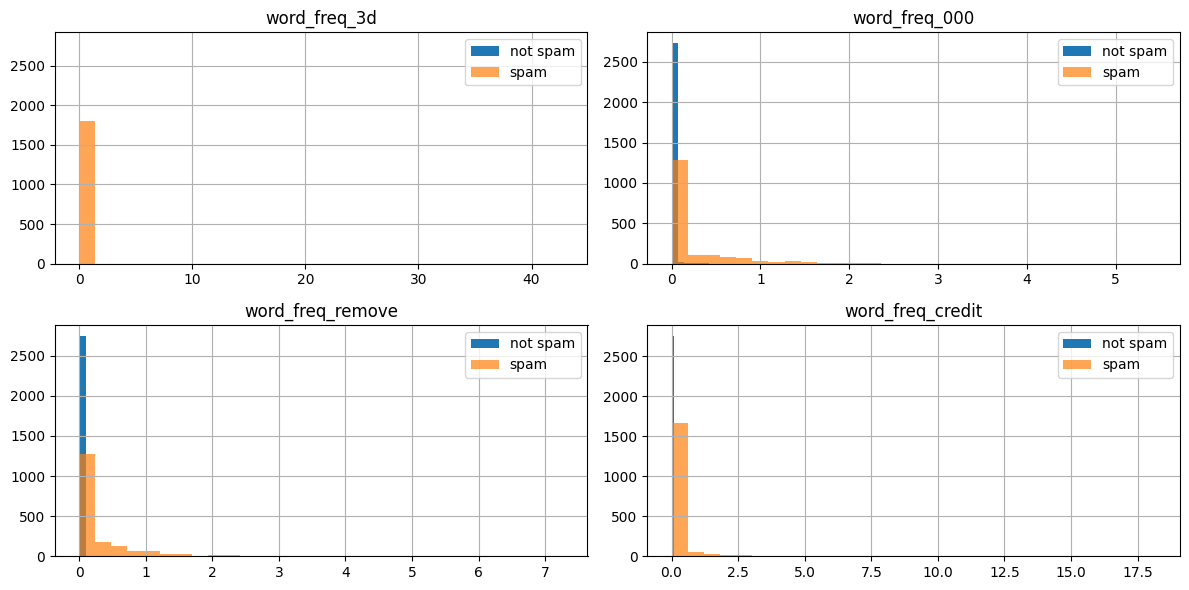

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
features_to_plot = ['word_freq_3d', 'word_freq_000', 'word_freq_remove', 'word_freq_credit']

for ax, feat in zip(axes.ravel(), features_to_plot):
    dataset[dataset['spam']==0][feat].hist(ax=ax, alpha=1, label='not spam', bins=30)
    dataset[dataset['spam']==1][feat].hist(ax=ax, alpha=0.7, label='spam', bins=30)
    ax.set_title(feat)
    ax.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [103]:
#x = sorted((dataset[dataset['spam'] == 1]['word_freq_3d']).to_numpy(), reverse = True)
#x[:50]

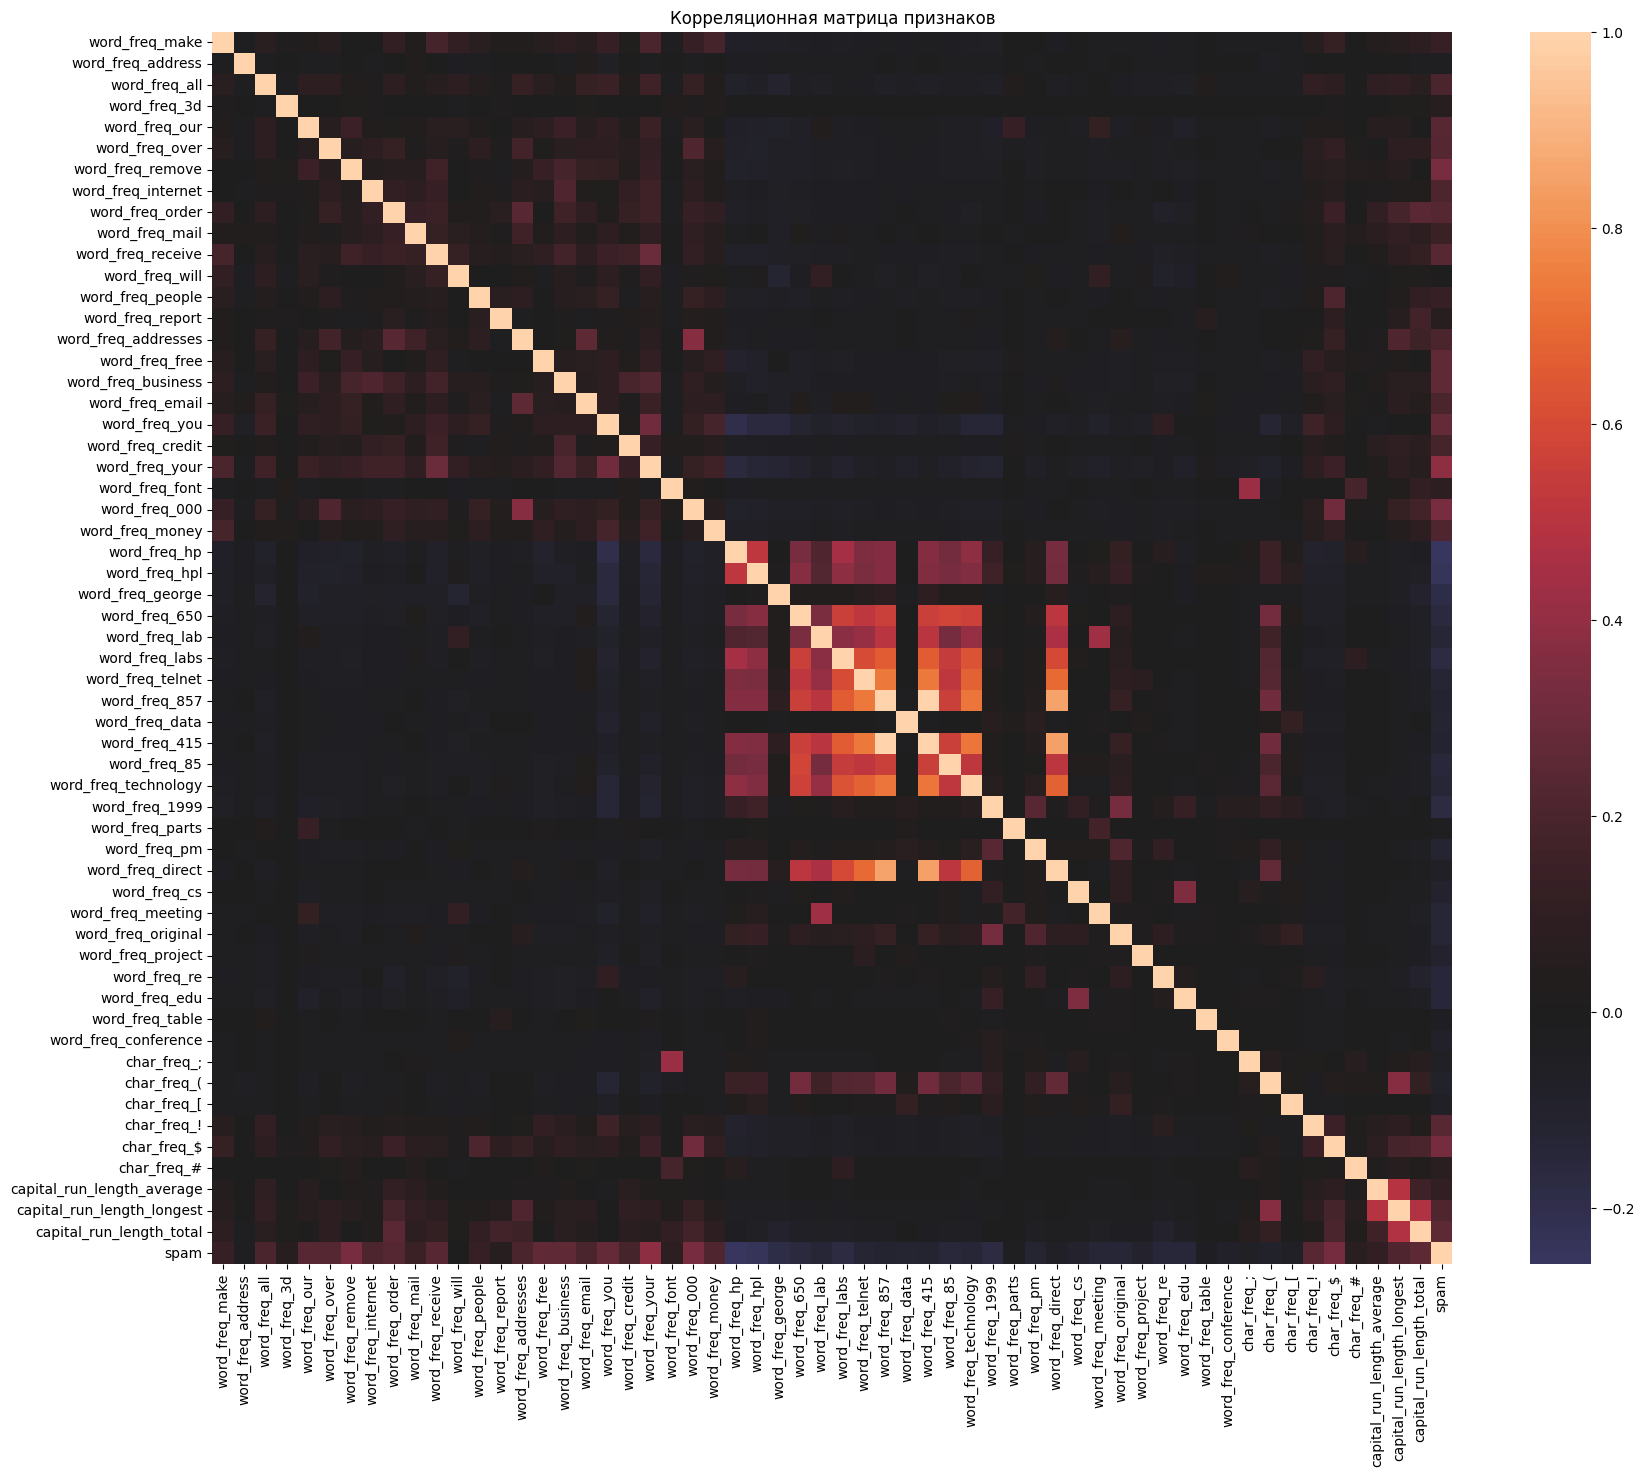

In [104]:
# Вычислим корреляцию
corr_matrix = dataset.corr()
#print(type(corr_matrix))
# Визуализируем
plt.figure(figsize=(20, 16))

sns.heatmap(corr_matrix, center=0, annot=False, fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

In [105]:
corr_with_spam = corr_matrix['spam'].sort_values(ascending=False)

print("Топ-10 признаков, коррелирующих со спамом:")
print(corr_with_spam[1:11])  # кроме самой spam

Топ-10 признаков, коррелирующих со спамом:
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_!                 0.241888
Name: spam, dtype: float64


Непосредственно начинаем машинное обучение

Подготовим данные. Применим процедуры сдвига и масштабирования

In [106]:
X = dataset.drop('spam', axis=1)
y = dataset['spam']
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% данных оставим для теста
    random_state=42,
    stratify=y               # сохраняем пропорции классов
)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Посмотрим на то, что мог бы нам дать метод главных компонент.


In [107]:
n_components = 53
pca = PCA(n_components=n_components)
X_pca_train = pca.fit_transform(X_train)
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")


Объясненная дисперсия: [0.11824283 0.05733768 0.03539854 0.02794696 0.02712179 0.02614975
 0.02520496 0.02406443 0.02307607 0.0223152  0.02111836 0.02031382
 0.01959424 0.01928632 0.01914644 0.01879037 0.01825965 0.01797933
 0.01794621 0.01755438 0.01740566 0.01721041 0.01687834 0.01651117
 0.01639254 0.01622178 0.01587141 0.01561839 0.01522173 0.01491882
 0.01462309 0.01437852 0.01398144 0.01376816 0.01336645 0.01307793
 0.01293022 0.01274685 0.01251385 0.01224509 0.01181987 0.01137943
 0.01091306 0.01064566 0.01027484 0.00972716 0.00884816 0.00855268
 0.00787401 0.0072234  0.00649532 0.00598605 0.00554309]


По всей видимости, метод главных компонент, конечно, позволяет редуцировать количество признаков, но в данной задаче он недостатоно эффективен. Для того, чтобы убедиться в этом наверняка построим зависимость объясненной дисперсии от количества главных компонент

Накопленная дисперсия для 5 компонент: 0.26604779869787554


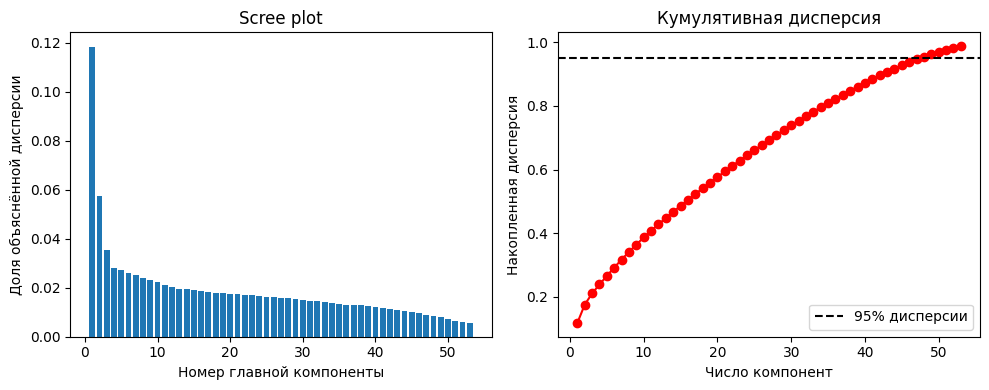

In [108]:
# Суммарная доля для первых k компонент
cumsum = np.cumsum(pca.explained_variance_ratio_)
print("Накопленная дисперсия для 5 компонент:", cumsum[4])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Scree plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Кумулятивная дисперсия')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% дисперсии')
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
# Находим минимальное число компонент для сохранения 95% дисперсии
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Для сохранения 95% дисперсии нужно {n_components_95} компонент")

Для сохранения 95% дисперсии нужно 48 компонент


Как мы видим из 53 признаков у нас оказывается 48, объясняющих 95% дисперсии. Но это крайне маленькое редуцирование, поэтому даже не будем его применять.

Также мы можем понять, что наши признаки слабо коррелированны. Данные не вытянуты вдоль какого-то одного признака, а "распределены равномерно" по всем признакам

Реализуем теперь **Логистическую регрессию**

In [110]:
model = LogisticRegression(max_iter=1000, fit_intercept = False)
_ = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Основные метрики по обучению модели представленны ниже.

In [111]:
print(classification_report(y_test, y_pred, target_names=['not spam', 'spam']))

              precision    recall  f1-score   support

    not spam       0.93      0.95      0.94       558
        spam       0.92      0.89      0.91       363

    accuracy                           0.93       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



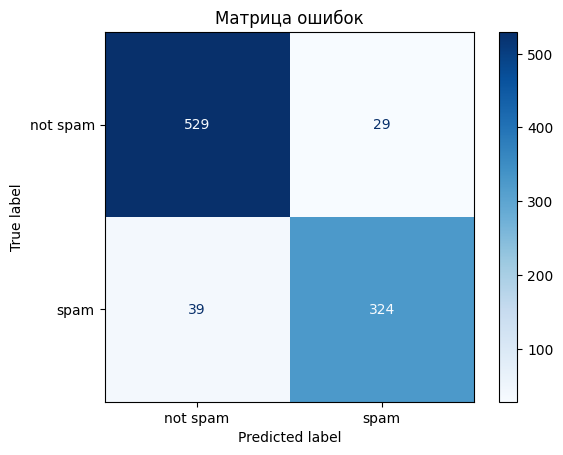

In [112]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not spam', 'spam'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок')
plt.show()


In [113]:
print(cm)

[[529  29]
 [ 39 324]]


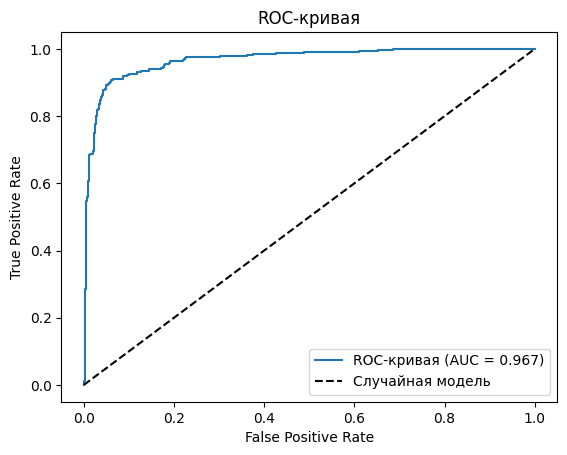

In [114]:
y_proba = model.predict_proba(X_test)   # вероятности (для ROC-AUC)
#print(y_proba[1:8,:])
#print(y_pred[1:8])
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])  # вероятности для класса "спам"
auc = roc_auc_score(y_test, y_proba[:, 1])

plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()


Мы совсем не использовали никаких регулизаторов, не настраивали гиперпараметры. Давайте проведем валидацию, посмотрим влияние гиперпараметров на нашу модель логистической регресии.

In [115]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']  # liblinear поддерживает l1 и l2
}
model = LogisticRegression()
grid = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
#results = pd.DataFrame(grid.cv_results_)


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='roc_auc')

In [116]:
print(grid.best_params_)
best_model = grid.best_estimator_
y_best_test = best_model.predict(X_test)
#print(f"Test accuracy: {accuracy_score(y_test, y_best_test):.4f}")
print(classification_report(y_test, y_best_test, digits = 5))

{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0    0.92982   0.94982   0.93972       558
           1    0.92023   0.88981   0.90476       363

    accuracy                        0.92617       921
   macro avg    0.92503   0.91981   0.92224       921
weighted avg    0.92604   0.92617   0.92594       921



До этого мы оптимизировали ROC-AUC метрику. Давайте теперь попробуем усилить неекоторый другие показатели, к примеру -- precision.

In [117]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 5, 10, 50, 75, 100]
}
strat_cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
model = LogisticRegression(solver = 'liblinear')
grid = GridSearchCV(estimator = model, param_grid = param_grid, cv=strat_cv, scoring='precision')
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=8, random_state=42, shuffle=True),
             estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.01, 0.1, 1, 5, 10, 50, 75, 100],
                         'penalty': ['l1', 'l2']},
             scoring='precision')

In [118]:
best_model = grid.best_estimator_
y_best_test = best_model.predict(X_test)
print(classification_report(y_test, y_best_test))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       558
           1       0.93      0.88      0.90       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



Попробуем теперь решить задачу классификации с помощью **Многослойной нейронной сети**

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [120]:
device = 'cuda'
device

'cuda'

Создадим специальный класс для Перцептрона и пропишем для него функции trainer и tester

In [121]:
class Perceptron(torch.nn.Module):
    @property
    def device(self):
        for p in self.parameters():
            return p.device

    def __init__(self, input_dim = 57, num_layers=0,
                 hidden_dim=64, output_dim=2, p=0.0):
        super(Perceptron, self).__init__()

        self.layers = torch.nn.Sequential()

        prev_size = input_dim
        for i in range(num_layers):
            self.layers.add_module('layer{}'.format(i),
                                  torch.nn.Linear(prev_size, hidden_dim, bias = True))
            self.layers.add_module('relu{}'.format(i), torch.nn.ReLU())
            self.layers.add_module('dropout{}'.format(i), torch.nn.Dropout(p=p))
            prev_size = hidden_dim

        self.layers.add_module('classifier',
                               torch.nn.Linear(prev_size, output_dim))

    def forward(self, input):
        return self.layers(input)

In [122]:
def testing(model, dataset):
    generator = torch.utils.data.DataLoader(dataset, batch_size=64)

    pred = []
    real = []
    for x, y in generator:
        x = x.to(device)
        y = y.to(device)

        pred.extend(torch.argmax(model(x), dim=-1).cpu().numpy().tolist())
        real.extend(y.cpu().numpy().tolist())

    return np.mean(np.array(real) == np.array(pred)), \
           classification_report(real, pred)

In [123]:
def trainer(model, dataset, loss_function, optimizer, epochs):
    for epoch in tqdm(range(epochs), leave=False):
        generator = torch.utils.data.DataLoader(dataset, batch_size=64,
                                                shuffle=True)
        for x, y in tqdm(generator, leave=False):
            optimizer.zero_grad()
            x = x.to(device)
            y = y.to(device)

            output = model(x)
            loss = loss_function(output, y)
            loss.backward()
            optimizer.step()

In [124]:
print(torch.cuda.is_available())

True


In [125]:
model = Perceptron()
#print(model.layers)
model.to(device)

Perceptron(
  (layers): Sequential(
    (classifier): Linear(in_features=57, out_features=2, bias=True)
  )
)

In [126]:
cross_val = KFold(n_splits=8, shuffle=True, random_state=42)
number_of_batch = cross_val.get_n_splits(X_train)
print(f"This is number of batch: {number_of_batch}")
grid = ParameterGrid({'num_layers': [5, 10],
                      'hidden_dim': [8, 64],
                      'p': [0.1, 0.5],
                      'lr': [0.01]})


This is number of batch: 8


In [127]:
def draw_table(data, title=['ACCURACY'], width=[60, 11]):
    row_format = '|' + '|'.join([("{:>"+str(w)+"}") for w in width]) + '|'
    row_format_bet = '+' + '+'.join([("{:>"+str(w)+"}") for w in width]) + '+'

    print(row_format_bet.format(
        "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))
    print(row_format.format("", *title))
    print(row_format_bet.format(
        "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))
    for key in data:
        if len(key) > width[0]:
            row_name = '...' + key[len(key)-width[0]+3:]
        else:
            row_name = key
        print(row_format.format(row_name, *[round(x, 2) for x in data[key]]))
        print(row_format_bet.format(
            "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))

In [ ]:
Y_train = y_train.to_numpy()
Y_test = y_test.to_numpy()

scores = dict()
for item in tqdm(grid, leave = False):

    list_of_scores = []
    for train_index, test_index in tqdm(cross_val.split(X_train),
                                        total=number_of_batch, leave=False):
        # Преобразование в тензоры
        X_train_t = torch.tensor(X_train[train_index], dtype=torch.float32)
        y_train_t = torch.tensor(Y_train[train_index], dtype=torch.long)
        X_test_t = torch.tensor(X_train[test_index], dtype=torch.float32)
        y_test_t = torch.tensor(Y_train[test_index], dtype=torch.long)


        train_dataset = TensorDataset(X_train_t, y_train_t)
        test_dataset = TensorDataset(X_test_t, y_test_t)

        model = Perceptron(num_layers=item['num_layers'], p=item['p'],
                           hidden_dim=item['hidden_dim'])
        model.to(device)
        _ = model.train()
        trainer(model=model,
                dataset=train_dataset,
                loss_function=torch.nn.CrossEntropyLoss(),
                optimizer=torch.optim.Adam(model.parameters(), lr=item['lr']),
                epochs=10)

        _ = model.eval()
        acc, report = testing(model, test_dataset)
        list_of_scores.append(acc)
    scores[str(item)] = [np.mean(list_of_scores)]



  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

...

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
draw_table(scores)

In [ ]:
best_params = sorted(scores,
                    key=lambda x: scores[x], reverse=True)[0]
print(best_params)

Имеет смысл в дальнейшем использовать модель, которая имеет размерность скрытого слоя 64, learning rate = 0.01, количество скртых слоев, равное 5 и вероятностью DropOut p=0.1

In [ ]:
model = Perceptron(hidden_dim = 64, p =0.1, num_layers = 5).to(device)
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
_ = model.train()
train_dataset = TensorDataset(X_train, Y_train)
trainer(model=model,
                dataset=train_dataset,
                loss_function=torch.nn.CrossEntropyLoss(),
                optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
                epochs=10)
_ = model.eval()
Y_test = torch.tensor(y_test.to_numpy(), dtype = torch.long)
X_test_fin = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(X_test_fin, Y_test)
acc, report = testing(model, test_dataset)
print(f"Accuracy of our model is:  {acc}\n")
print(f"Classification report:\n{report}")

In [ ]:
import json, os
from google.colab import files

# Путь к ноутбуку в Colab. Обычно файл лежит здесь:
src = '/content/drive/MyDrive/Colab_Notebooks/project_spambase.ipynb'

#/content/drive/MyDrive/Colab_Notebooks/project_spambase.ipynb
# Если файл лежит в другом месте — поменяй src на правильный путь.
# Посмотреть где он, можно через панель слева (иконка папки).

with open(src) as f:
    nb = json.load(f)

# Убираем сломанные metadata виджетов
nb.get('metadata', {}).pop('widgets', None)
for cell in nb.get('cells', []):
    cell.get('metadata', {}).pop('widgets', None)

out = '/content/drive/MyDrive/Colab_Notebooks/project_spambase.ipynb'
with open(out, 'w') as f:
    json.dump(nb, f, indent=1)

files.download(out)
print('Готово. Файл скачается автоматически.')

In [ ]:
#import nbformat

#filename = 'project_spambase.ipynb'
#with open(filename, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Удаляем блок с виджетами, если он поврежден
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

with open(filename, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)


Итоговые выводы

* Наиболее информативные признаки для обнаружения спама – это частоты слов your, 000, remove, you, free, business, our, а также символы $ и ! и общее количество заглавных букв. Эти признаки имеют корреляцию со спамом от 0.24 до 0.38.
* Метод главных компонент (PCA) оказался неэффективным для этого набора данных, так как признаки слабо коррелируют между собой. Для сохранения 95% дисперсии потребовалось 48 компонент из 57 – редукция незначительна.
* Логистическая регрессия с L1-регуляризацией (штраф Lasso) показала лучший результат: accuracy 93%, ROC-AUC 0.967.
* Настройка гиперпараметров позволила достичь компромисса между precision и recall. В частности, мы смогли повысить precision спама до 0.93, пожертвовав recall (0.88).
* Многослойная нейронная сеть (перцептрон с 5 скрытыми слоями) дала accuracy 92.
2%, что незначительно хуже. Учитывая большую сложность и время обучения, для данной задачи предпочтительнее использовать логистическую регрессию – она проще в интерпретации и быстрее работает.